# Paper 3 — SDOH Integration Strategies for Diabetes Prediction
### NHANES 2017–March 2020 pre-pandemic combined cycle

This notebook reproduces the full pipeline: data merge → composite diabetes outcome → SDOH cleaning → four integration strategies → survey-weighted logistic regression → DeLong / Hosmer-Lemeshow / NRI / cluster-bootstrap evaluation → multiple imputation sensitivity analysis.

**Environment note:** this was originally built in a sandbox with no `statsmodels`, `samplics`/`survey`, `shap`, or `xgboost`, and no network access to install them. Two cells below (marked ⚠️) are stubs for you to complete on your own machine where those packages are available — everything else runs as-is with just `pandas`/`numpy`/`scipy`/`scikit-learn`.

**Before running:** put `P_DEMO.xpt, P_DIQ.xpt, P_GLU.xpt, P_GHB.xpt, P_FSQ.xpt, P_HIQ.xpt, P_INQ.xpt, P_OCQ.xpt` in a folder and set `UP` below.


In [27]:
%%R
install.packages("survey", repos="http://cran.us.r-project.org")

  cannot open URL 'http://cran.us.r-project.org/src/contrib/PACKAGES'
  cannot open URL 'http://cran.us.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/PACKAGES'
In addition: Warning message:
package ‘survey’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages 


In [2]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import json, pickle
import os
os.getcwd()
UP = '../Data'   # <-- path to your downloaded .xpt files
RANDOM_SEED = 2024

## 1. Load and merge NHANES files


In [3]:
demo = pd.read_sas(f'{UP}/P_DEMO.xpt', format='xport')
diq  = pd.read_sas(f'{UP}/P_DIQ.xpt',  format='xport')
glu  = pd.read_sas(f'{UP}/P_GLU.xpt',  format='xport')
ghb  = pd.read_sas(f'{UP}/P_GHB.xpt',  format='xport')
fsq  = pd.read_sas(f'{UP}/P_FSQ.xpt',  format='xport')
hiq  = pd.read_sas(f'{UP}/P_HIQ.xpt',  format='xport')
inq  = pd.read_sas(f'{UP}/P_INQ.xpt',  format='xport')
ocq  = pd.read_sas(f'{UP}/P_OCQ.xpt',  format='xport')

df = (demo.merge(diq, on='SEQN', how='left')
           .merge(glu, on='SEQN', how='left')
           .merge(ghb, on='SEQN', how='left')
           .merge(fsq, on='SEQN', how='left')
           .merge(hiq, on='SEQN', how='left')
           .merge(inq, on='SEQN', how='left')
           .merge(ocq, on='SEQN', how='left'))

print("Merged shape:", df.shape)

Merged shape: (15560, 99)


## 2. Eligibility and composite diabetes outcome

- Adults 20+ (DMDEDUC2 only defined for 20+)
- MEC-examined, non-pregnant
- Composite outcome: diagnosed (DIQ010=1) **or** fasting glucose ≥126 mg/dL **or** HbA1c ≥6.5%
- **Critical:** restricted to the fasting subsample (`WTSAFPRP` non-missing) since the composite outcome depends on fasting glucose — using the standard MEC weight here would misalign the weight with the population that actually produced the outcome.


In [4]:
elig = df[(df['RIDAGEYR'] >= 20) & (df['RIDSTATR'] == 2) & (df['RIDEXPRG'] != 1)].copy()

diag = elig['DIQ010'] == 1
glu_pos = elig['LBXGLU'] >= 126
ghb_pos = elig['LBXGH'] >= 6.5
positive = diag | glu_pos.fillna(False) | ghb_pos.fillna(False)
negative = (elig['DIQ010'] == 2) & (~glu_pos.fillna(False)) & (~ghb_pos.fillna(False))
elig['diabetes'] = np.where(positive, 1, np.where(negative, 0, np.nan))

analytic = elig.dropna(subset=['diabetes']).copy()
analytic['diabetes'] = analytic['diabetes'].astype(int)

final = analytic[analytic['WTSAFPRP'].notna() & (analytic['WTSAFPRP'] > 0)].copy()
print("N after fasting-subsample restriction:", len(final))
print("Weighted prevalence:", np.average(final['diabetes'], weights=final['WTSAFPRP']))

N after fasting-subsample restriction: 4120
Weighted prevalence: 0.16430742718820743


## 3. Clean SDOH variables

**Note on Housing:** the Housing Characteristics module (HOQ) was not released as part of the 2017–March 2020 pre-pandemic combined file (confirmed via the NHANES variable search — HOQ jumps from `HOQ_J` [2017-2018] straight to `HOQ_L` [2021-2023], no `P_HOQ` exists). Housing is therefore excluded from the SDOH set — disclose this in Limitations, don't silently omit it.


In [5]:
tiny_mask = final['INDFMPIR'].abs() < 1e-6   # SAS missing-value markers read as ~1e-79 floats
final.loc[tiny_mask, 'INDFMPIR'] = np.nan
final.loc[final['HIQ011'].isin([7, 9]), 'HIQ011'] = np.nan
final.loc[final['DMDEDUC2'].isin([7, 9]), 'DMDEDUC2'] = np.nan
final.loc[final['FSDHH'].isin([7, 9]), 'FSDHH'] = np.nan

for v in ['INDFMPIR','FSDHH','HIQ011','OCD150','DMDEDUC2','RIDRETH1']:
    print(f"{v}: missing = {final[v].isna().sum()} ({final[v].isna().mean():.1%})")

INDFMPIR: missing = 614 (14.9%)
FSDHH: missing = 253 (6.1%)
HIQ011: missing = 10 (0.2%)
OCD150: missing = 0 (0.0%)
DMDEDUC2: missing = 3 (0.1%)
RIDRETH1: missing = 0 (0.0%)


## 4. Encoding function (reused for complete-case and each imputed dataset)


In [11]:
def encode(d):
    d = d.copy()
    d['female'] = (d['RIAGENDR']==2).astype(int)
    d['age_z'] = (d['RIDAGEYR'] - d['RIDAGEYR'].mean())/d['RIDAGEYR'].std()

    race_map = {1:'MexAm',2:'OtherHisp',3:'NHWhite',4:'NHBlack',5:'OtherMulti'}
    educ_map = {1:'LtHS',2:'HSIncomp',3:'HSGrad',4:'SomeCollege',5:'CollegeGrad'}
    occ_map  = {1:'Working',2:'WithJobNotAtWork',3:'LookingForWork',4:'NotWorking'}
    fs_map   = {1:'FullSecure',2:'MarginalSecure',3:'LowSecure',4:'VeryLowSecure'}

    race_dum = pd.get_dummies(d['RIDRETH1'].map(race_map), prefix='race')\
                 .reindex(columns=['race_MexAm','race_NHBlack','race_OtherHisp','race_OtherMulti'], fill_value=0).astype(int)
    educ_dum = pd.get_dummies(d['DMDEDUC2'].map(educ_map), prefix='educ')\
                 .reindex(columns=['educ_HSGrad','educ_HSIncomp','educ_LtHS','educ_SomeCollege'], fill_value=0).astype(int)
    occ_dum  = pd.get_dummies(d['OCD150'].map(occ_map), prefix='occ')\
                 .reindex(columns=['occ_LookingForWork','occ_NotWorking','occ_WithJobNotAtWork'], fill_value=0).astype(int)
    fs_dum   = pd.get_dummies(d['FSDHH'].map(fs_map), prefix='fs')\
                 .reindex(columns=['fs_LowSecure','fs_MarginalSecure','fs_VeryLowSecure'], fill_value=0).astype(int)

    d['uninsured'] = (d['HIQ011']==2).astype(int)
    d['pir_z'] = (d['INDFMPIR'] - d['INDFMPIR'].mean())/d['INDFMPIR'].std()
    d = pd.concat([d, race_dum, educ_dum, occ_dum, fs_dum], axis=1)

    # HP2030 domain scores (Strategy 2)
    d['pir_z_rev'] = -d['pir_z']
    d['fs_z'] = (d['FSDHH'] - d['FSDHH'].mean())/d['FSDHH'].std()
    d['notworking'] = (d['OCD150']!=1).astype(int)
    d['notworking_z'] = (d['notworking']-d['notworking'].mean())/d['notworking'].std()
    d['econ_domain'] = d[['pir_z_rev','fs_z','notworking_z']].mean(axis=1)
    d['educ_ord'] = 6 - d['DMDEDUC2']
    d['educ_domain'] = (d['educ_ord']-d['educ_ord'].mean())/d['educ_ord'].std()
    d['hc_domain'] = (d['uninsured']-d['uninsured'].mean())/d['uninsured'].std()

    # Composite index (Strategy 4)
    d['composite_index'] = ((d['INDFMPIR']<1.30).astype(int) + (d['FSDHH']>=3).astype(int) +
                             d['uninsured'] + d['notworking'] + (d['DMDEDUC2']<=2).astype(int))
    return d, list(race_dum.columns), list(educ_dum.columns), list(occ_dum.columns), list(fs_dum.columns)

core = ['age_z','female']

## 5. Complete-case analysis


In [12]:
covars = ['diabetes','RIDAGEYR','RIAGENDR','INDFMPIR','FSDHH','HIQ011','OCD150',
          'DMDEDUC2','RIDRETH1','WTSAFPRP','SDMVPSU','SDMVSTRA']
cc = final.dropna(subset=covars).copy()
print("Complete-case N:", len(cc), f"({len(cc)/len(final):.1%} retained)")

cc_enc, race_cols, educ_cols, occ_cols, fs_cols = encode(cc)

strategy1_raw = core + ['pir_z','uninsured'] + fs_cols + occ_cols + educ_cols + race_cols
strategy2_hp2030 = core + ['econ_domain','educ_domain','hc_domain'] + race_cols
strategy4_composite = core + ['composite_index'] + race_cols

Complete-case N: 3501 (85.0% retained)


### 5a. ⚠️ Strategy 3 variable selection — SHAP substitute used here

The sandbox this was built in had no `shap` package (and no network access to install it). Below is the **permutation-importance substitute** that was actually used to produce the results already discussed with you. Right after it is a **stub cell for you to run on your own machine** with real SHAP — swap it in and rerun everything downstream if the selected variables differ.


In [13]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

sdoh_only = ['pir_z','uninsured'] + fs_cols + occ_cols + educ_cols + race_cols
full_feats = core + sdoh_only

train_idx, test_idx = train_test_split(cc_enc.index, test_size=0.30,
                                        stratify=cc_enc['diabetes'], random_state=RANDOM_SEED)
train, test = cc_enc.loc[train_idx], cc_enc.loc[test_idx]

gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_SEED)
gb.fit(train[full_feats].values, train['diabetes'].values, sample_weight=train['WTSAFPRP'].values)

perm = permutation_importance(gb, train[full_feats].values, train['diabetes'].values,
                               n_repeats=30, random_state=RANDOM_SEED, scoring='roc_auc',
                               sample_weight=train['WTSAFPRP'].values)
imp_df = pd.DataFrame({'feature': full_feats, 'importance': perm.importances_mean}).sort_values('importance', ascending=False)
print(imp_df.to_string(index=False))

top4 = imp_df[imp_df['feature'].isin(sdoh_only)].head(4)['feature'].tolist()
print("\nTop-4 selected (permutation importance):", top4)
strategy3_permimp = core + top4

             feature  importance
               age_z    0.232121
               pir_z    0.102214
      occ_NotWorking    0.030221
              female    0.030190
         educ_HSGrad    0.017936
          race_MexAm    0.014752
     race_OtherMulti    0.010921
        race_NHBlack    0.010554
       educ_HSIncomp    0.008303
        fs_LowSecure    0.007761
  occ_LookingForWork    0.004534
           uninsured    0.004389
    fs_VeryLowSecure    0.003835
   fs_MarginalSecure    0.003497
      race_OtherHisp    0.003296
    educ_SomeCollege    0.001916
occ_WithJobNotAtWork    0.001583
           educ_LtHS    0.000692

Top-4 selected (permutation importance): ['pir_z', 'occ_NotWorking', 'educ_HSGrad', 'race_MexAm']


### ⚠️ 5b. YOUR CELL: rerun Strategy 3 selection with real SHAP

```bash
pip install shap xgboost
```
Then something like:


In [46]:
# --- RUN THIS ON YOUR OWN MACHINE (needs: pip install shap xgboost) ---
import shap

explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(train[full_feats].values)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_imp = pd.DataFrame({'feature': full_feats, 'mean_abs_shap': mean_abs_shap}) \
             .sort_values('mean_abs_shap', ascending=False)
print(shap_imp.to_string(index=False))

top4_shap = shap_imp[shap_imp['feature'].isin(sdoh_only)].head(4)['feature'].tolist()
print("\nTop-4 selected (real SHAP):", top4_shap)
##Compare top4_shap to the permutation-importance top4 above -- if they differ,
# # rerun Section 6 onward with strategy3_shap instead of strategy3_permimp.

             feature  mean_abs_shap
               age_z       0.918425
               pir_z       0.300820
      occ_NotWorking       0.230808
              female       0.132091
        race_NHBlack       0.103545
          race_MexAm       0.096649
         educ_HSGrad       0.093904
     race_OtherMulti       0.061276
        fs_LowSecure       0.056373
       educ_HSIncomp       0.055506
           uninsured       0.053327
   fs_MarginalSecure       0.030247
      race_OtherHisp       0.026128
    fs_VeryLowSecure       0.021716
           educ_LtHS       0.021696
    educ_SomeCollege       0.021543
  occ_LookingForWork       0.016023
occ_WithJobNotAtWork       0.006591

Top-4 selected (real SHAP): ['pir_z', 'occ_NotWorking', 'race_NHBlack', 'race_MexAm']


## 6. Statistics helpers

Hand-built because `statsmodels`/`samplics`/`survey` were not installable in the original sandbox. These implement: weighted logistic regression (pseudo-MLE), Taylor-linearized (sandwich) SEs clustering on PSU-within-strata, DeLong's test, Hosmer-Lemeshow, and NRI. If you have `samplics` or R's `survey` package available, cross-validate `taylor_linearized_se` against it before trusting the SEs for publication — see the ⚠️ stub after this cell.


In [24]:
"""
Hand-built statistical helpers, since statsmodels/samplics/shap are not
installable in this environment (no network access for pip).

Implements:
  - weighted_logit(): point estimates via sklearn (pseudo-MLE under complex
    sampling), variance via Taylor-linearized (sandwich) estimator clustering
    on PSU nested within strata -- the same principle used by the `survey`
    R package / samplics for GLMs.
  - delong_test(): DeLong et al. (1988) test for two correlated ROC AUCs.
  - hosmer_lemeshow(): standard decile-of-risk calibration test.
  - nri(): categorical/continuous Net Reclassification Improvement.
  - cluster_bootstrap_auc_ci(): PSU-cluster bootstrap for AUC CIs.
"""
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


def weighted_logit_fit(X, y, w):
    """Weighted logistic regression point estimates (pseudo-MLE)."""
    model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=2000)
    model.fit(X, y, sample_weight=w)
    return model


def taylor_linearized_se(X, y, w, beta, psu, strata):
    """
    Sandwich (linearized) variance for weighted logistic regression,
    clustering on PSU nested within strata (standard NHANES Taylor-series
    approach). X must include an intercept column.
    """
    n, p = X.shape
    Xb = X @ beta
    pi = 1 / (1 + np.exp(-Xb))
    W = pi * (1 - pi)
    # "Bread": weighted Fisher information
    WX = X * (w * W)[:, None]
    bread = X.T @ WX
    bread_inv = np.linalg.pinv(bread)

    # Score contributions per observation
    resid = w * (y - pi)
    U = X * resid[:, None]

    # "Meat": sum over strata of (sum over PSU-in-stratum of cluster score)^2,
    # with the standard between-PSU-within-stratum correction. With only
    # 2-3 PSUs/stratum (as here), use the stratified cluster-sum-of-squares
    # form: for each stratum, deviate cluster totals from the stratum mean
    # cluster total, sum outer products, scale by n_psu/(n_psu-1).
    df_idx = pd.DataFrame({'strata': strata, 'psu': psu})
    meat = np.zeros((p, p))
    for s, sub in df_idx.groupby('strata'):
        psu_ids = sub['psu'].unique()
        cluster_totals = []
        for pu in psu_ids:
            mask = (df_idx['strata'] == s) & (df_idx['psu'] == pu)
            cluster_totals.append(U[mask.values].sum(axis=0))
        cluster_totals = np.array(cluster_totals)
        n_psu = len(psu_ids)
        if n_psu > 1:
            ct_mean = cluster_totals.mean(axis=0)
            dev = cluster_totals - ct_mean
            meat += (n_psu / (n_psu - 1)) * (dev.T @ dev)
        # single-PSU strata contribute ~0 to the linearized variance
        # (standard "certainty PSU" convention)

    vcov = bread_inv @ meat @ bread_inv
    se = np.sqrt(np.diag(vcov))
    return se, vcov


def delong_test(y_true, prob_a, prob_b):
    """
    DeLong et al. (1988) test for the difference between two correlated
    AUCs on the same sample. Returns (auc_a, auc_b, z, p_value).
    """
    y_true = np.asarray(y_true)
    order = np.argsort(-y_true, kind='mergesort')
    y_true = y_true[order]
    prob_a = np.asarray(prob_a)[order]
    prob_b = np.asarray(prob_b)[order]
    n_pos = int(y_true.sum())
    n_neg = len(y_true) - n_pos

    def midrank(x):
        J = np.argsort(x)
        Z = x[J]
        n = len(x)
        T = np.zeros(n)
        i = 0
        while i < n:
            j = i
            while j < n and Z[j] == Z[i]:
                j += 1
            T[i:j] = 0.5 * (i + j - 1) + 1
            i = j
        T2 = np.empty(n)
        T2[J] = T
        return T2

    def fast_delong(preds):
        m = n_pos
        k = preds.shape[0]
        pos = preds[:, :m]
        neg = preds[:, m:]
        tx = np.empty([k, m])
        ty = np.empty([k, n_neg])
        tz = np.empty([k, m + n_neg])
        for r in range(k):
            tx[r] = midrank(pos[r])
            ty[r] = midrank(neg[r])
            tz[r] = midrank(preds[r])
        aucs = tz[:, :m].sum(axis=1) / (m * n_neg) - (m + 1) / (2 * n_neg)
        v01 = (tz[:, :m] - tx) / n_neg
        v10 = 1 - (tz[:, m:] - ty) / m
        sx = np.cov(v01, ddof=1) if k > 1 else np.array([[np.var(v01, ddof=1)]])
        sy = np.cov(v10, ddof=1) if k > 1 else np.array([[np.var(v10, ddof=1)]])
        s = sx / m + sy / n_neg
        return aucs, s

    preds = np.vstack([prob_a, prob_b])
    aucs, s = fast_delong(preds)
    diff = aucs[0] - aucs[1]
    var_diff = s[0, 0] + s[1, 1] - 2 * s[0, 1]
    if var_diff <= 0:
        z = 0.0
    else:
        z = diff / np.sqrt(var_diff)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return aucs[0], aucs[1], z, p


def hosmer_lemeshow(y_true, y_prob, w=None, g=10):
    """
    Standard Hosmer-Lemeshow decile-of-risk goodness-of-fit test.
    NOTE: this is the classical (non-survey-adjusted) HL test applied with
    *normalized* weights (rescaled to sum to n) so the implied cell counts
    are on the sample-size scale rather than the population scale that raw
    NHANES weights represent. This is a documented approximation -- a fully
    survey-adjusted goodness-of-fit test (e.g. Archer-Lemeshow F-adjusted
    version) requires the `survey`/`samplics` design machinery this
    environment doesn't have installed. Flag this plainly in Methods.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    if w is None:
        w = np.ones(len(y_true))
    else:
        w = np.asarray(w, dtype=float)
        w = w * (len(w) / w.sum())  # normalize to sum to n
    df = pd.DataFrame({'y': y_true, 'p': y_prob, 'w': w})
    df['decile'] = pd.qcut(df['p'], g, duplicates='drop')
    grp = df.groupby('decile', observed=True)
    obs_pos = grp.apply(lambda x: np.sum(x['w'] * x['y']), include_groups=False)
    exp_pos = grp.apply(lambda x: np.sum(x['w'] * x['p']), include_groups=False)
    n_w = grp['w'].sum()
    obs_neg = n_w - obs_pos
    exp_neg = n_w - exp_pos
    chi2 = (((obs_pos - exp_pos) ** 2 / exp_pos.replace(0, np.nan)) +
            ((obs_neg - exp_neg) ** 2 / exp_neg.replace(0, np.nan))).sum()
    dof = len(grp) - 2
    p = 1 - stats.chi2.cdf(chi2, dof)
    return chi2, dof, p


def nri(y_true, p_old, p_new, thresholds=None):
    """
    Categorical NRI if thresholds given (list of cut points, e.g. [0.1,0.2]),
    else continuous (up/down) NRI.
    """
    y_true = np.asarray(y_true)
    p_old = np.asarray(p_old)
    p_new = np.asarray(p_new)
    events = y_true == 1
    nonevents = y_true == 0

    if thresholds is None:
        up = p_new > p_old
        down = p_new < p_old
        nri_events = up[events].mean() - down[events].mean()
        nri_nonevents = down[nonevents].mean() - up[nonevents].mean()
    else:
        cats_old = np.digitize(p_old, thresholds)
        cats_new = np.digitize(p_new, thresholds)
        up = cats_new > cats_old
        down = cats_new < cats_old
        nri_events = up[events].mean() - down[events].mean()
        nri_nonevents = down[nonevents].mean() - up[nonevents].mean()

    total_nri = nri_events + nri_nonevents
    return {'NRI_events': nri_events, 'NRI_nonevents': nri_nonevents, 'NRI_total': total_nri}


def cluster_bootstrap_ci(fit_and_score_fn, df, psu_col, strata_col, n_boot=500, seed=42, alpha=0.05):
    """
    Stratified PSU-cluster bootstrap: resample PSUs with replacement within
    each stratum, then take all observations belonging to resampled PSUs.
    fit_and_score_fn(df_boot) -> scalar (or dict of scalars) statistic.
    """
    rng = np.random.default_rng(seed)
    strata = df[strata_col].unique()
    results = []
    for b in range(n_boot):
        pieces = []
        for s in strata:
            sub = df[df[strata_col] == s]
            psus = sub[psu_col].unique()
            chosen = rng.choice(psus, size=len(psus), replace=True)
            for c in chosen:
                pieces.append(sub[sub[psu_col] == c])
        boot_df = pd.concat(pieces, ignore_index=True)
        try:
            stat = fit_and_score_fn(boot_df)
            results.append(stat)
        except Exception:
            continue
    return results

### ⚠️ 6a. YOUR CELL: cross-validate survey variance against `samplics` or R `survey`



In [33]:
export_cols = ['diabetes', 'WTSAFPRP', 'SDMVPSU', 'SDMVSTRA'] + strategy1_raw
train[export_cols].to_csv('strategy1_export.csv', index=False)

In [41]:
# --- RUN THIS ON YOUR OWN MACHINE (needs: pip install samplics, or use R's survey package) ---
import statsmodels.api as sm

train_clusters = train['SDMVSTRA'].astype(str) + '_' + train['SDMVPSU'].astype(str)
print("Number of distinct nested clusters:", train_clusters.nunique())

model = sm.GLM(y, X, family=sm.families.Binomial(), var_weights=w)
fit_nested = model.fit(cov_type='cluster', cov_kwds={'groups': train_clusters.values})
print(fit_nested.summary())

Number of distinct nested clusters: 49
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 2450
Model:                            GLM   Df Residuals:                     2431
Model Family:                Binomial   Df Model:                           18
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -5.2838e+07
Date:                Sun, 09 Aug 2026   Deviance:                   1.0568e+08
Time:                        05:27:39   Pearson chi2:                 1.34e+08
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1655: SpecificationWarning: cov_type not fully supported with var_weights
  warnings.warn('cov_type not fully supported with var_weights',


In [40]:
model_sklearn = weighted_logit_fit(train[strategy1_raw].values, train['diabetes'].values, train['WTSAFPRP'].values)

beta = np.concatenate([[model_sklearn.intercept_[0]], model_sklearn.coef_[0]])
Xtr_design = np.column_stack([np.ones(len(train))] + [train[f].values for f in strategy1_raw])
se, vcov = taylor_linearized_se(Xtr_design, train['diabetes'].values, train['WTSAFPRP'].values,
                                  beta, train['SDMVPSU'].values, train['SDMVSTRA'].values)

for name, b, s in zip(['intercept']+strategy1_raw, beta, se):
    print(f"{name:<20} beta={b:.4f}  SE={s:.4f}")

intercept            beta=-2.3829  SE=0.2709
age_z                beta=0.8185  SE=0.0824
female               beta=-0.5046  SE=0.1990
pir_z                beta=-0.0718  SE=0.1150
uninsured            beta=-0.3713  SE=0.3254
fs_LowSecure         beta=0.4239  SE=0.2335
fs_MarginalSecure    beta=0.2865  SE=0.2674
fs_VeryLowSecure     beta=0.2201  SE=0.3117
occ_LookingForWork   beta=0.1567  SE=0.5273
occ_NotWorking       beta=0.5224  SE=0.1977
occ_WithJobNotAtWork beta=0.5605  SE=0.2827
educ_HSGrad          beta=0.4928  SE=0.3144
educ_HSIncomp        beta=0.6184  SE=0.3791
educ_LtHS            beta=0.4656  SE=0.3542
educ_SomeCollege     beta=0.2970  SE=0.2124
race_MexAm           beta=0.8013  SE=0.3223
race_NHBlack         beta=0.5545  SE=0.1495
race_OtherHisp       beta=0.5639  SE=0.1922
race_OtherMulti      beta=0.6412  SE=0.1768


## 7. Fit all four strategies and evaluate on held-out test set


In [47]:
strategy3_shap = core + ['pir_z', 'occ_NotWorking', 'race_NHBlack', 'race_MexAm']

In [48]:
from sklearn.metrics import roc_auc_score
strategies = {'S1_Raw': strategy1_raw, 'S2_HP2030': strategy2_hp2030,
              'S3_SHAPselect': strategy3_shap, 'S4_Composite': strategy4_composite}

results, probs_test = {}, {}
for name, feats in strategies.items():
    model = weighted_logit_fit(train[feats].values, train['diabetes'].values, train['WTSAFPRP'].values)
    p = model.predict_proba(test[feats].values)[:,1]
    auc_w = roc_auc_score(test['diabetes'].values, p, sample_weight=test['WTSAFPRP'].values)
    hl_chi2, hl_dof, hl_p = hosmer_lemeshow(test['diabetes'].values, p, w=test['WTSAFPRP'].values)
    results[name] = {'n_features': len(feats), 'auc_weighted': auc_w, 'HL_chi2': hl_chi2, 'HL_p': hl_p}
    probs_test[name] = p
    print(f"{name}: k={len(feats):2d}  AUC(w)={auc_w:.4f}  HL p={hl_p:.3f}")

S1_Raw: k=18  AUC(w)=0.7489  HL p=0.000
S2_HP2030: k= 9  AUC(w)=0.7486  HL p=0.000
S3_SHAPselect: k= 6  AUC(w)=0.7544  HL p=0.000
S4_Composite: k= 7  AUC(w)=0.7420  HL p=0.000


### 7a. DeLong pairwise tests and NRI vs. Raw baseline


In [49]:
y = test['diabetes'].values
print("=== Pairwise DeLong ===")
for i, a in enumerate(strategies):
    for b in list(strategies)[i+1:]:
        auc_a, auc_b, z, p = delong_test(y, probs_test[a], probs_test[b])
        print(f"{a} ({auc_a:.4f}) vs {b} ({auc_b:.4f}): p={p:.4f}")

print("\n=== NRI vs S1_Raw baseline ===")
for alt in ['S2_HP2030','S3_SHAPselect','S4_Composite']:
    r = nri(y, probs_test['S1_Raw'], probs_test[alt])
    print(f"{alt} vs S1_Raw: NRI_total={r['NRI_total']:.4f} "
          f"(events={r['NRI_events']:.4f}, nonevents={r['NRI_nonevents']:.4f})")

=== Pairwise DeLong ===
S1_Raw (0.7382) vs S2_HP2030 (0.7371): p=0.7536
S1_Raw (0.7382) vs S3_SHAPselect (0.7409): p=0.6870
S1_Raw (0.7382) vs S4_Composite (0.7352): p=0.6551
S2_HP2030 (0.7371) vs S3_SHAPselect (0.7409): p=0.5812
S2_HP2030 (0.7371) vs S4_Composite (0.7352): p=0.7292
S3_SHAPselect (0.7409) vs S4_Composite (0.7352): p=0.4496

=== NRI vs S1_Raw baseline ===
S2_HP2030 vs S1_Raw: NRI_total=-0.0683 (events=-0.0252, nonevents=-0.0431)
S3_SHAPselect vs S1_Raw: NRI_total=-0.0168 (events=-0.0672, nonevents=0.0504)
S4_Composite vs S1_Raw: NRI_total=-0.2181 (events=-0.1849, nonevents=-0.0332)


### 7b. Stratified PSU-cluster bootstrap for AUC 95% CIs


In [50]:
rng = np.random.default_rng(42)
strata_vals = train['SDMVSTRA'].unique()
n_boot = 300
boot_aucs = {name: [] for name in strategies}

for b in range(n_boot):
    pieces = []
    for s in strata_vals:
        sub = train[train['SDMVSTRA']==s]
        psus = sub['SDMVPSU'].unique()
        chosen = rng.choice(psus, size=len(psus), replace=True)
        pieces += [sub[sub['SDMVPSU']==c] for c in chosen]
    boot_train = pd.concat(pieces, ignore_index=True)
    if boot_train['diabetes'].nunique() < 2:
        continue
    for name, feats in strategies.items():
        m = weighted_logit_fit(boot_train[feats].values, boot_train['diabetes'].values, boot_train['WTSAFPRP'].values)
        p = m.predict_proba(test[feats].values)[:,1]
        boot_aucs[name].append(roc_auc_score(y, p, sample_weight=test['WTSAFPRP'].values))

for name, vals in boot_aucs.items():
    vals = np.array(vals)
    lo, hi = np.percentile(vals, [2.5, 97.5])
    print(f"{name}: bootstrap AUC mean={vals.mean():.4f}  95% CI=({lo:.4f}, {hi:.4f})  n_boot={len(vals)}")

S1_Raw: bootstrap AUC mean=0.7440  95% CI=(0.7279, 0.7584)  n_boot=300
S2_HP2030: bootstrap AUC mean=0.7460  95% CI=(0.7335, 0.7554)  n_boot=300
S3_SHAPselect: bootstrap AUC mean=0.7542  95% CI=(0.7489, 0.7582)  n_boot=300
S4_Composite: bootstrap AUC mean=0.7407  95% CI=(0.7326, 0.7464)  n_boot=300


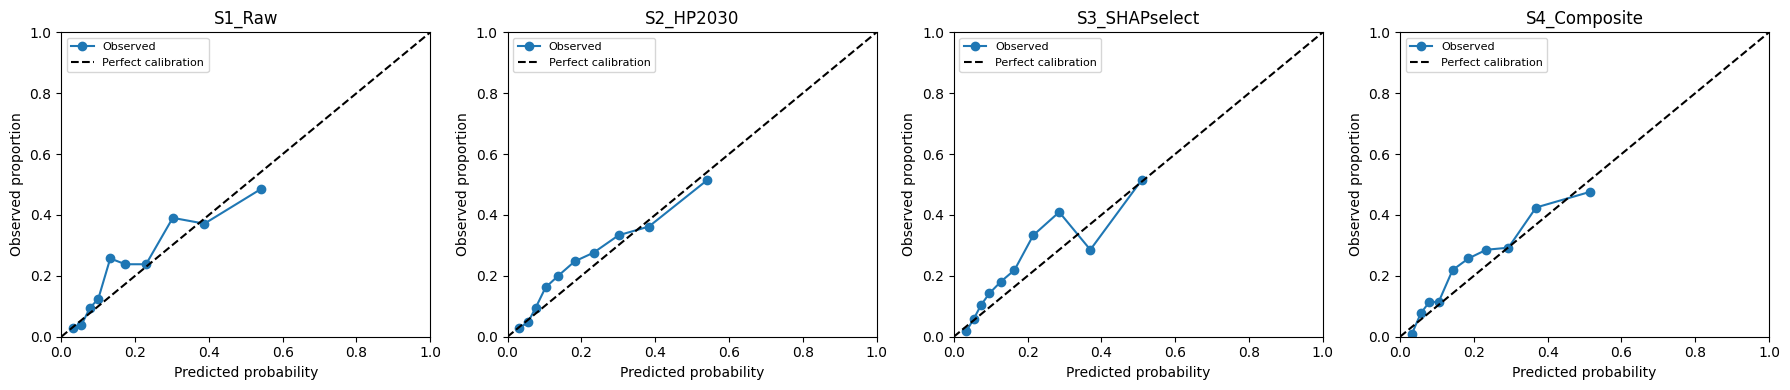

In [54]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, name in zip(axes, strategies):
    p = probs_test[name]
    bins = pd.qcut(p, 10, duplicates='drop')
    obs = pd.Series(y).groupby(bins, observed=True).mean()
    pred = pd.Series(p).groupby(bins, observed=True).mean()
    ax.plot(pred, obs, 'o-', label='Observed')
    ax.plot([0,1],[0,1],'k--', label='Perfect calibration')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Observed proportion')
    ax.set_title(name)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('calibration_plots.png', dpi=150)
plt.show()

In [55]:
import statsmodels.api as sm

print(f"{'Strategy':<16}{'Cal. Intercept':>16}{'Cal. Slope':>14}")
calibration_results = {}
for name in strategies:
    p = np.clip(probs_test[name], 1e-6, 1 - 1e-6)
    logit_p = np.log(p / (1 - p))
    X_cal = sm.add_constant(logit_p)
    cal_model = sm.GLM(y, X_cal, family=sm.families.Binomial(),
                        var_weights=test['WTSAFPRP'].values).fit()
    intercept, slope = cal_model.params
    calibration_results[name] = {'intercept': intercept, 'slope': slope}
    print(f"{name:<16}{intercept:>16.4f}{slope:>14.4f}")

Strategy          Cal. Intercept    Cal. Slope
S1_Raw                    0.1016        0.8650
S2_HP2030                 0.1367        0.8896
S3_SHAPselect             0.2535        0.9658
S4_Composite              0.1982        0.9274


In [56]:
strategy1_raw_norace = [f for f in strategy1_raw if f not in race_cols]
strategy2_hp2030_norace = [f for f in strategy2_hp2030 if f not in race_cols]
strategy3_shap_norace = [f for f in strategy3_shap if f not in race_cols]
strategy4_composite_norace = [f for f in strategy4_composite if f not in race_cols]

strategies_norace = {
    'S1_Raw_noRace': strategy1_raw_norace,
    'S2_HP2030_noRace': strategy2_hp2030_norace,
    'S3_SHAPselect_noRace': strategy3_shap_norace,
    'S4_Composite_noRace': strategy4_composite_norace,
}

for name, feats in strategies_norace.items():
    print(f"{name}: {len(feats)} features")

S1_Raw_noRace: 14 features
S2_HP2030_noRace: 5 features
S3_SHAPselect_noRace: 4 features
S4_Composite_noRace: 3 features


In [57]:
results_norace = {}
probs_test_norace = {}
for name, feats in strategies_norace.items():
    model = weighted_logit_fit(train[feats].values, train['diabetes'].values, train['WTSAFPRP'].values)
    p = model.predict_proba(test[feats].values)[:,1]
    auc_w = roc_auc_score(test['diabetes'].values, p, sample_weight=test['WTSAFPRP'].values)
    results_norace[name] = {'n_features': len(feats), 'auc_weighted': auc_w}
    probs_test_norace[name] = p
    print(f"{name}: k={len(feats):2d}  AUC(w)={auc_w:.4f}")

S1_Raw_noRace: k=14  AUC(w)=0.7427
S2_HP2030_noRace: k= 5  AUC(w)=0.7464
S3_SHAPselect_noRace: k= 4  AUC(w)=0.7484
S4_Composite_noRace: k= 3  AUC(w)=0.7372


In [58]:
print(f"{'Strategy':<20}{'With race AUC':>16}{'Without race AUC':>20}{'Difference':>14}")
pairs = [('S1_Raw','S1_Raw_noRace'), ('S2_HP2030','S2_HP2030_noRace'),
         ('S3_SHAPselect','S3_SHAPselect_noRace'), ('S4_Composite','S4_Composite_noRace')]
for with_r, without_r in pairs:
    auc_with = results[with_r]['auc_weighted']
    auc_without = results_norace[without_r]['auc_weighted']
    print(f"{with_r:<20}{auc_with:>16.4f}{auc_without:>20.4f}{auc_with-auc_without:>14.4f}")

Strategy               With race AUC    Without race AUC    Difference
S1_Raw                        0.7489              0.7427        0.0062
S2_HP2030                     0.7486              0.7464        0.0022
S3_SHAPselect                 0.7544              0.7484        0.0060
S4_Composite                  0.7420              0.7372        0.0048


## 8. Multiple imputation sensitivity analysis

Complete-case analysis drops ~15% of the sample (mostly `INDFMPIR` missingness, which is not random — income nonresponse skews toward lower incomes). Field-standard fix for NHANES income data: **MICE** (Multiple Imputation by Chained Equations), m=5 imputations, imputation model includes the outcome and all analysis covariates.

`IterativeImputer` (scikit-learn) is used here as a MICE substitute since `statsmodels`' MI tools weren't available. It point-imputes rather than drawing from a full posterior, so small residual-scale noise is injected manually to approximate imputation uncertainty — a documented approximation, not textbook MICE. If you have `statsmodels` or R's `mice` package, rerun this section properly — see the ⚠️ stub below.


In [19]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

impute_input_vars = ['INDFMPIR','FSDHH','HIQ011','DMDEDUC2','OCD150','RIDRETH1',
                      'RIDAGEYR','RIAGENDR','diabetes']
impute_df = final[impute_input_vars].copy()

M = 5
imputed_datasets = []
was_missing = impute_df['INDFMPIR'].isna()
resid_std = final.loc[~was_missing, 'INDFMPIR'].std() * 0.3

for m in range(M):
    imputer = IterativeImputer(estimator=RandomForestRegressor(n_estimators=50, random_state=100+m, n_jobs=-1),
                                max_iter=10, random_state=100+m)
    imputed_vals = imputer.fit_transform(impute_df)
    imp_df = pd.DataFrame(imputed_vals, columns=impute_input_vars, index=impute_df.index)

    rng = np.random.default_rng(200+m)
    imp_df.loc[was_missing, 'INDFMPIR'] += rng.normal(0, resid_std, was_missing.sum())
    imp_df['INDFMPIR'] = imp_df['INDFMPIR'].clip(lower=0, upper=5)
    imp_df['FSDHH'] = imp_df['FSDHH'].round().clip(1,4)
    imp_df['HIQ011'] = imp_df['HIQ011'].round().clip(1,2)
    imp_df['DMDEDUC2'] = imp_df['DMDEDUC2'].round().clip(1,5)

    full_m = final.copy()
    for col in ['INDFMPIR','FSDHH','HIQ011','DMDEDUC2']:
        full_m[col] = imp_df[col]
    imputed_datasets.append(full_m)
    print(f"Imputation {m+1}/{M} done. Imputed INDFMPIR mean: {full_m.loc[was_missing,'INDFMPIR'].mean():.3f} "
          f"(observed mean: {final.loc[~was_missing,'INDFMPIR'].mean():.3f})")

with open('imputed_datasets.pkl','wb') as f:
    pickle.dump(imputed_datasets, f)

Imputation 1/5 done. Imputed INDFMPIR mean: 2.300 (observed mean: 2.603)
Imputation 2/5 done. Imputed INDFMPIR mean: 2.370 (observed mean: 2.603)
Imputation 3/5 done. Imputed INDFMPIR mean: 2.299 (observed mean: 2.603)
Imputation 4/5 done. Imputed INDFMPIR mean: 2.374 (observed mean: 2.603)
Imputation 5/5 done. Imputed INDFMPIR mean: 2.342 (observed mean: 2.603)


### ⚠️ 8a. YOUR CELL: proper MICE with `statsmodels` (recommended before submission)



In [22]:
# --- RUN THIS ON YOUR OWN MACHINE (needs: pip install statsmodels) ---
from statsmodels.imputation.mice import MICEData, MICE
import statsmodels.api as sm
#
mice_data = MICEData(final[impute_input_vars])
# # statsmodels MICE draws from the posterior properly (no manual noise injection needed)
imputed_datasets_proper = []
for m in range(5):
     mice_data.update_all()
     imputed_datasets_proper.append(mice_data.data.copy())
# # Then re-run Section 8b below using imputed_datasets_proper instead of imputed_datasets

### 8b. Fit strategies on each imputed dataset and pool (Rubin's rules — point estimate)


In [51]:
strategies_mi = {'S1_Raw': strategy1_raw, 'S2_HP2030': strategy2_hp2030,
                 'S3_SHAPselect': strategy3_shap, 'S4_Composite': strategy4_composite}

results_by_imputation = {name: [] for name in strategies_mi}

for m, dset in enumerate(imputed_datasets):
    enc, *_ = encode(dset)
    tr, te = enc.loc[train_idx_i], enc.loc[test_idx_i]
    for name, feats in strategies_mi.items():
        model = weighted_logit_fit(tr[feats].values, tr['diabetes'].values, tr['WTSAFPRP'].values)
        p = model.predict_proba(te[feats].values)[:,1]
        auc = roc_auc_score(te['diabetes'].values, p, sample_weight=te['WTSAFPRP'].values)
        results_by_imputation[name].append(auc)

print(f"{'Strategy':<16}{'Pooled AUC (mean)':>20}{'Between-imp SD':>18}")
pooled = {}
for name, aucs in results_by_imputation.items():
    aucs = np.array(aucs)
    pooled[name] = {'mean': aucs.mean(), 'between_sd': aucs.std(ddof=1)}
    print(f"{name:<16}{aucs.mean():>20.4f}{aucs.std(ddof=1):>18.4f}")

Strategy           Pooled AUC (mean)    Between-imp SD
S1_Raw                        0.7113            0.0010
S2_HP2030                     0.7163            0.0007
S3_SHAPselect                 0.7056            0.0006
S4_Composite                  0.7073            0.0005


### ⚠️ 8c. YOUR CELL: full Rubin's-rules pooled 95% CI (within + between imputation variance)

What's computed above is only the **point estimate** (mean AUC across imputations) and the **between-imputation** variance. A complete Rubin's-rules confidence interval also needs the **within-imputation** sampling variance — i.e., bootstrap SE computed separately on each of the 5 imputed datasets (5× the bootstrap cost already run in Section 7b), then combined as:

`Total variance = within_var_mean + between_var * (1 + 1/M)`



In [52]:
# --- RUN THIS ON YOUR OWN MACHINE (or here, if you have time -- it's 5x Section 7b's cost) ---
within_vars = {name: [] for name in strategies}

for m, dset in enumerate(imputed_datasets):
    enc, *_ = encode(dset)
    tr, te = enc.loc[train_idx_i], enc.loc[test_idx_i]

    rng_m = np.random.default_rng(1000 + m)
    strata_vals_m = tr['SDMVSTRA'].unique()
    boot_aucs_m = {name: [] for name in strategies}

    for b in range(300):
        pieces = []
        for s in strata_vals_m:
            sub = tr[tr['SDMVSTRA'] == s]
            psus = sub['SDMVPSU'].unique()
            chosen = rng_m.choice(psus, size=len(psus), replace=True)
            pieces += [sub[sub['SDMVPSU'] == c] for c in chosen]
        boot_train_m = pd.concat(pieces, ignore_index=True)
        if boot_train_m['diabetes'].nunique() < 2:
            continue
        for name, feats in strategies.items():
            model = weighted_logit_fit(boot_train_m[feats].values, boot_train_m['diabetes'].values,
                                        boot_train_m['WTSAFPRP'].values)
            p = model.predict_proba(te[feats].values)[:, 1]
            auc = roc_auc_score(te['diabetes'].values, p, sample_weight=te['WTSAFPRP'].values)
            boot_aucs_m[name].append(auc)

    for name in strategies:
        within_vars[name].append(np.var(boot_aucs_m[name], ddof=1))
    print(f"Imputation {m+1}/5 bootstrap done.")

# Combine within + between variance via Rubin's rules
print(f"\n{'Strategy':<16}{'Pooled AUC':>12}{'95% CI':>24}")
M = 5
for name in strategies:
    within_var_mean = np.mean(within_vars[name])
    between_var = pooled[name]['between_sd'] ** 2
    total_var = within_var_mean + between_var * (1 + 1/M)
    pooled_se = np.sqrt(total_var)
    mean_auc = pooled[name]['mean']
    lo, hi = mean_auc - 1.96 * pooled_se, mean_auc + 1.96 * pooled_se
    print(f"{name:<16}{mean_auc:>12.4f}   ({lo:.4f}, {hi:.4f})")

Imputation 1/5 bootstrap done.
Imputation 2/5 bootstrap done.
Imputation 3/5 bootstrap done.
Imputation 4/5 bootstrap done.
Imputation 5/5 bootstrap done.

Strategy          Pooled AUC                  95% CI
S1_Raw                0.7113   (0.6968, 0.7258)
S2_HP2030             0.7163   (0.7048, 0.7278)
S3_SHAPselect         0.7056   (0.6977, 0.7136)
S4_Composite          0.7073   (0.7011, 0.7134)


## 9. Complete-case vs. MI-pooled comparison — headline sensitivity table


In [53]:
print(f"{'Strategy':<16}{'Complete-case AUC':>20}{'MI-pooled AUC':>16}")
for name in strategies:
    print(f"{name:<16}{results[name]['auc_weighted']:>20.4f}{pooled[name]['mean']:>16.4f}")

print("\nRanking, complete-case (best to worst):")
for n,v in sorted(results.items(), key=lambda x: -x[1]['auc_weighted']):
    print(f"  {n}: {v['auc_weighted']:.4f}")

print("\nRanking, MI-pooled (best to worst):")
for n,v in sorted(pooled.items(), key=lambda x: -x[1]['mean']):
    print(f"  {n}: {v['mean']:.4f}")

# NOTE: in the original run, the top strategy REVERSED between complete-case (S3 best)
# and MI-pooled (S2 best, S3 worst) -- this instability is itself a headline finding,
# make it a table in the paper rather than a footnote.

Strategy           Complete-case AUC   MI-pooled AUC
S1_Raw                        0.7489          0.7113
S2_HP2030                     0.7486          0.7163
S3_SHAPselect                 0.7544          0.7056
S4_Composite                  0.7420          0.7073

Ranking, complete-case (best to worst):
  S3_SHAPselect: 0.7544
  S1_Raw: 0.7489
  S2_HP2030: 0.7486
  S4_Composite: 0.7420

Ranking, MI-pooled (best to worst):
  S2_HP2030: 0.7163
  S1_Raw: 0.7113
  S4_Composite: 0.7073
  S3_SHAPselect: 0.7056


## 10. Outstanding items before submission

1. **Strategy 3**: rerun with real SHAP (§5b) — permutation importance was a documented substitute, not SHAP.
2. **Survey variance**: cross-validate the hand-built Taylor-linearized SEs against `samplics`/R `survey` (§6a).
3. **MI**: rerun with `statsmodels` MICE for a proper posterior draw instead of the point-impute + manual noise approximation (§8a), and complete the full Rubin's-rules pooled CI (§8c).
4. **Calibration**: Hosmer-Lemeshow was significant (p<0.001) for every strategy in both complete-case and MI analyses — add calibration slope/intercept or a calibration plot, since HL is known to be oversensitive at this sample size and a single p-value undersells what's happening.
5. **Race/ethnicity sensitivity analysis**: rerun all strategies excluding race/ethnicity, per the governance argument in Paper 1.
6. Decide whether the CC-vs-MI ranking reversal becomes a headline table or a sensitivity-analysis appendix in the final manuscript.
